
📊 Matriz de confusión:
[[25  0  0]
 [ 0  6  2]
 [ 1  0 56]]

📝 Informe de clasificación:
              precision    recall  f1-score   support

        Alto       0.96      1.00      0.98        25
        Bajo       1.00      0.75      0.86         8
    Moderado       0.97      0.98      0.97        57

    accuracy                           0.97        90
   macro avg       0.98      0.91      0.94        90
weighted avg       0.97      0.97      0.97        90


🧠 Predicción para individuo personalizado:
  Ritmo cardíaco: 95, Cortisol: 20, Conductancia: 7
  → Nivel estimado de estrés: Alto


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/stress_scatter.png'

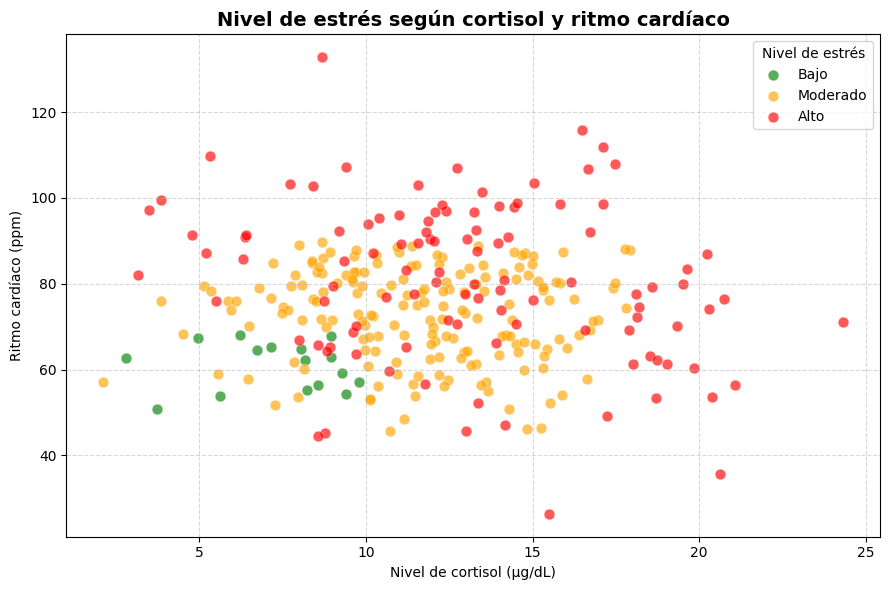

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


# Clase que representa una persona con medidas fisiológicas
class Individual:
    def __init__(self, heart_rate, cortisol_level, skin_conductance, stress_level):
        self.heart_rate = heart_rate
        self.cortisol_level = cortisol_level
        self.skin_conductance = skin_conductance
        self.stress_level = stress_level

    def to_vector(self):
        return [self.heart_rate, self.cortisol_level, self.skin_conductance]


# Generador de datos simulados
class StressDataGenerator:
    def __init__(self, n=300):
        self.n = n

    def generate(self):
        np.random.seed(42)
        heart_rates      = np.random.normal(75, 15, self.n)
        cortisol_levels  = np.random.normal(12,  4, self.n)
        conductances     = np.random.normal( 5, 1.5, self.n)

        individuals = []
        for hr, cl, sc in zip(heart_rates, cortisol_levels, conductances):
            # Reglas de clasificación
            if hr > 90 or cl > 18 or sc > 6.5:
                level = 'Alto'
            elif hr > 70 or cl > 10 or sc > 4.5:
                level = 'Moderado'
            else:
                level = 'Bajo'
            individuals.append(Individual(hr, cl, sc, level))

        return individuals


# Clasificador con Random Forest
class StressClassifier:
    def __init__(self):
        self.model = RandomForestClassifier(n_estimators=100, random_state=1)

    def fit(self, individuals):
        X = [ind.to_vector() for ind in individuals]
        y = [ind.stress_level for ind in individuals]
        self.model.fit(X, y)

    def predict(self, heart_rate, cortisol, conductance):
        X = [[heart_rate, cortisol, conductance]]
        return self.model.predict(X)[0]

    def evaluate(self, test_data):
        X_test = [ind.to_vector() for ind in test_data]
        y_test = [ind.stress_level for ind in test_data]
        y_pred = self.model.predict(X_test)

        print("\n📊 Matriz de confusión:")
        print(confusion_matrix(y_test, y_pred, labels=['Alto', 'Bajo', 'Moderado']))

        print("\n📝 Informe de clasificación:")
        print(classification_report(y_test, y_pred, labels=['Alto', 'Bajo', 'Moderado']))


# Ejecución y visualización
class StressAnalysisExample:
    def run(self):
        # 1. Generación de datos
        generator   = StressDataGenerator(n=300)
        individuals = generator.generate()

        # 2. División entrenamiento / prueba (70% / 30%)
        train_data, test_data = train_test_split(
            individuals, test_size=0.3, random_state=42
        )

        # 3. Entrenamiento y evaluación
        classifier = StressClassifier()
        classifier.fit(train_data)
        classifier.evaluate(test_data)

        # 4. Predicción personalizada
        hr, cl, sc = 95, 20, 7
        prediction = classifier.predict(hr, cl, sc)
        print("\n🧠 Predicción para individuo personalizado:")
        print(f"  Ritmo cardíaco: {hr}, Cortisol: {cl}, Conductancia: {sc}")
        print(f"  → Nivel estimado de estrés: {prediction}")

        # 5. Visualización
        df = pd.DataFrame(
            [ind.to_vector() + [ind.stress_level] for ind in individuals],
            columns=['heart_rate', 'cortisol_level', 'skin_conductance', 'stress_level']
        )

        color_map = {'Bajo': 'green', 'Moderado': 'orange', 'Alto': 'red'}
        colors    = df['stress_level'].map(color_map)

        plt.figure(figsize=(9, 6))
        for level, color in color_map.items():
            subset = df[df['stress_level'] == level]
            plt.scatter(
                subset['cortisol_level'],
                subset['heart_rate'],
                c=color,
                label=level,
                alpha=0.65,
                edgecolors='white',
                linewidths=0.4,
                s=60
            )

        plt.title('Nivel de estrés según cortisol y ritmo cardíaco', fontsize=14, fontweight='bold')
        plt.xlabel('Nivel de cortisol (µg/dL)')
        plt.ylabel('Ritmo cardíaco (ppm)')
        plt.legend(title='Nivel de estrés')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.savefig('/mnt/user-data/outputs/stress_scatter.png', dpi=150)
        plt.show()
        print("\n✅ Gráfico guardado como stress_scatter.png")


# Ejecutar ejemplo
example = StressAnalysisExample()
example.run()